# Extract Data from Documents via Annotations

---

## Annotations for Structured Outputs and Data Extraction
In this cookbook, we will explore the basics of Annotations and to achieve structured outputs fueled by our OCR model.

You may want to do this in case current vision models are not powerful enough, hence enhancing their vision OCR capabilities with the OCR model to achieve better structured data extraction.


## What are Annotations?

Mistral Document AI API adds two annotation functionalities:
- `document_annotation`: returns the annotation of the entire document based on the input schema.
- `box_annotation`: gives you the annotation of the bboxes extracted by the OCR model (charts/ figures etc) based on user requirement. The user may ask to describe/caption the figure for instance.

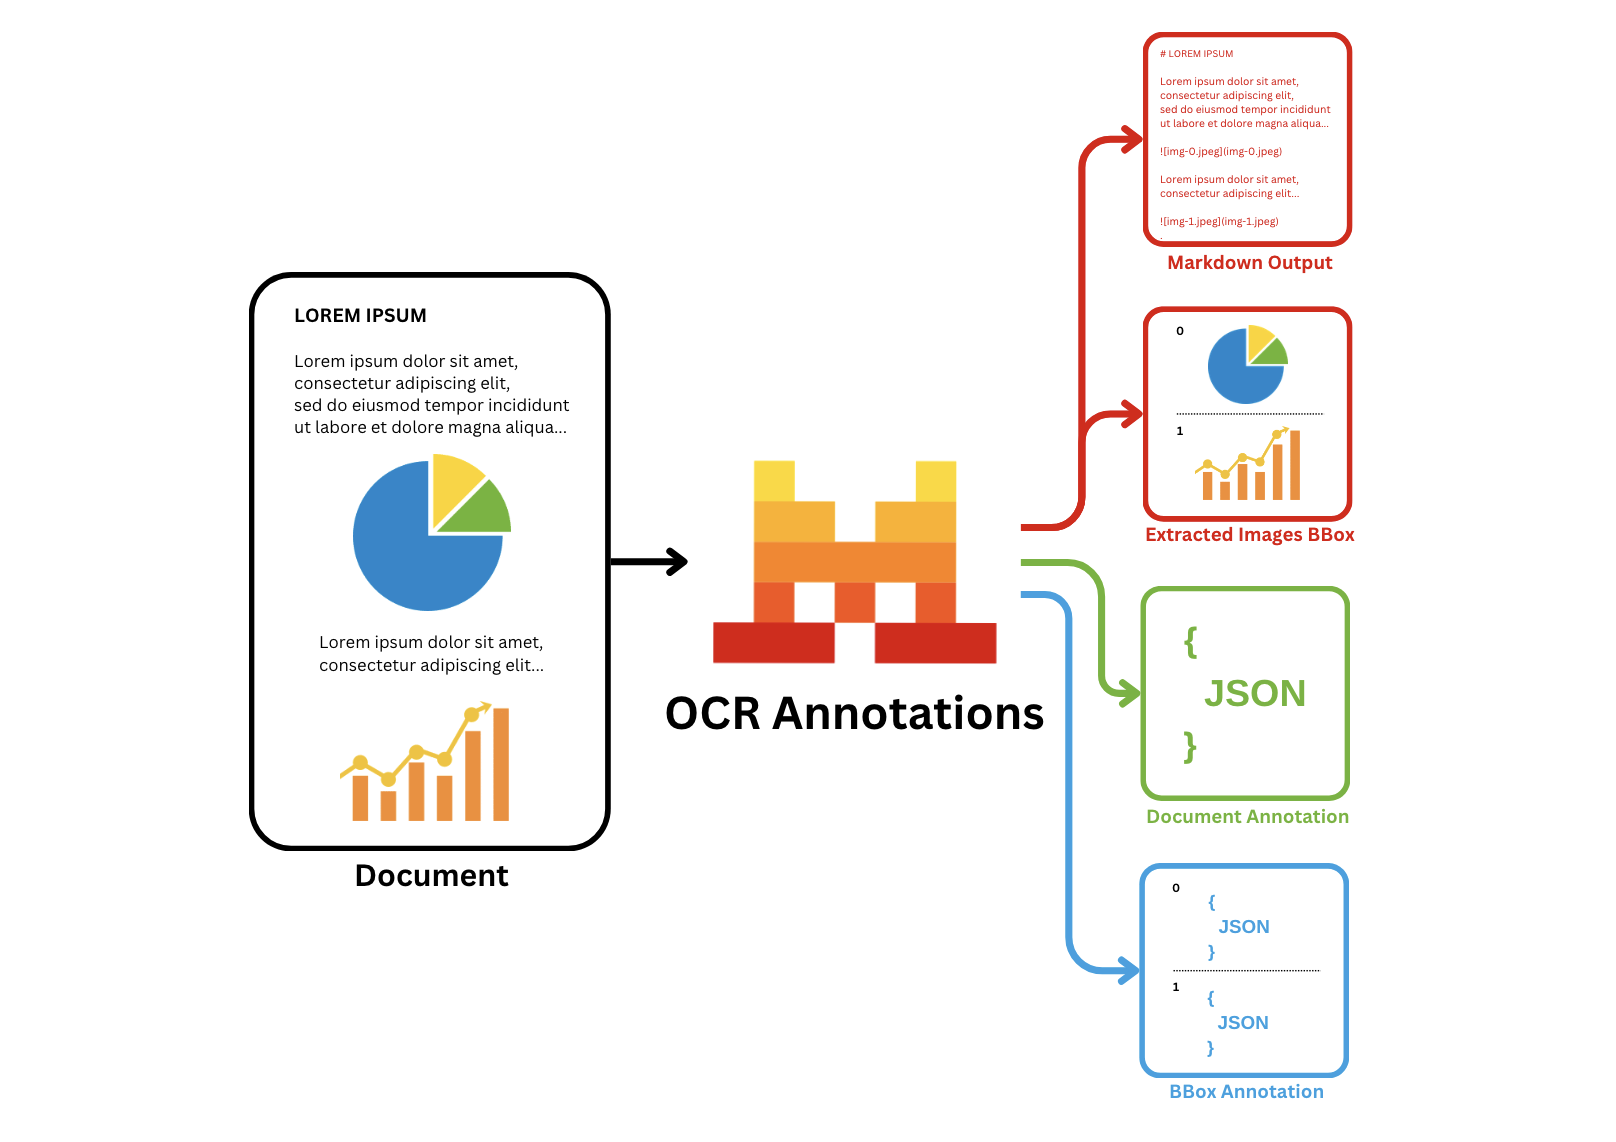

Learn more about Annotations [here](https://docs.mistral.ai/capabilities/OCR/annotations/).

## Setup

First, let's install `mistralai` and download the required files.

In [1]:
%%capture
!pip install mistralai markdown

### Download PDF

In [2]:
%%capture
!wget https://raw.githubusercontent.com/mistralai/cookbook/refs/heads/main/mistral/ocr/mistral7b.pdf

### Create Client

We will need to set up our client. You can create an API key on [AI Studio](https://console.mistral.ai/api-keys/).

In [3]:
# Initialize Mistral client with API key
from mistralai.client import Mistral

api_key = "API_KEY" # Replace with your API key
client = Mistral(api_key=api_key)

## Mistral OCR without Annotations
For our cookbook we will use a pdf file, annotate it and extract data from the document.

First we have to make a function to encode our pdf file in base64, you can also upload the file to our cloud and use a signed url instead.

In [4]:
import base64

def encode_pdf(pdf_path):
    """Encode the pdf to base64."""
    try:
        with open(pdf_path, "rb") as pdf_file:
            return base64.b64encode(pdf_file.read()).decode('utf-8')
    except FileNotFoundError:
        print(f"Error: The file {pdf_path} was not found.")
        return None
    except Exception as e:  # Added general exception handling
        print(f"Error: {e}")
        return None

Now with our function ready, we can encode our pdf file and call our OCR model.

In [5]:
import requests
import os
import json

# Path to your pdf
pdf_path = "mistral7b.pdf"

# Getting the base64 string
base64_pdf = encode_pdf(pdf_path)

# Call the OCR API
pdf_response = client.ocr.process(
    model="mistral-ocr-latest",
    document={
        "type": "document_url",
        "document_url": f"data:application/pdf;base64,{base64_pdf}"
    },
    include_image_base64=True,
    extract_header=True,
	extract_footer=True,
	confidence_scores_granularity="word" # Optional
)

# Convert response to JSON format
response_dict = json.loads(pdf_response.model_dump_json())

{
    "pages": [
        {
            "index": 0,
            "markdown": "arXiv:2310.06825v1 [cs.CL] 10 Oct 2023\n\n# Mistral 7B\n\nAlbert Q. Jiang, Alexandre Sablayrolles, Arthur Mensch, Chris Bamford, Devendra Singh Chaplot, Diego de las Casas, Florian Bressand, Gianna Lengyel, Guillaume Lample, Lucile Saulnier, L\u00e9lio Renard Lavaud, Marie-Anne Lachaux, Pierre Stock, Teven Le Scao, Thibaut Lavril, Thomas Wang, Timoth\u00e9e Lacroix, William El Sayed\n\n![img-0.jpeg](img-0.jpeg)\n\n## Abstract\n\nWe introduce Mistral 7B, a 7-billion-parameter language model engineered for superior performance and efficiency. Mistral 7B outperforms the best open 13B model (Llama 2) across all evaluated benchmarks, and the best released 34B model (Llama 1) in reasoning, mathematics, and code generation. Our model leverages grouped-query attention (GQA) for faster inference, coupled with sliding window attention (SWA) to effectively handle sequences of arbitrary length with a reduced inference cost
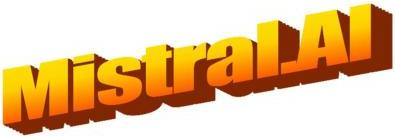
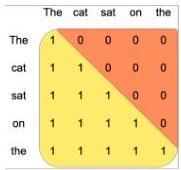
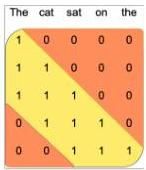
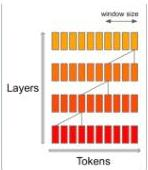
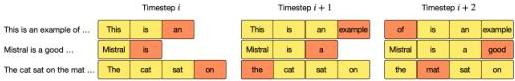
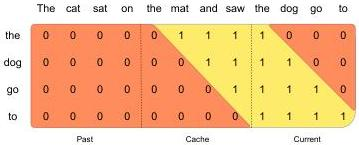
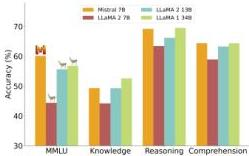
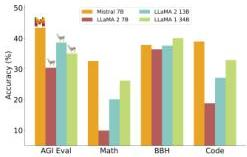
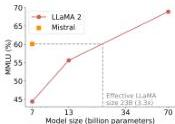
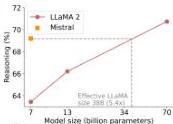
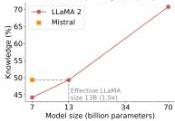
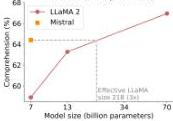
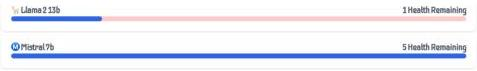
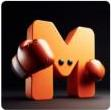

In [6]:
# @title Displays Truncated Output
def truncate_display(d):
    "Truncates confidence levels and blocks to fit in the google colab output cell."
    if isinstance(d, dict):
        if "word_confidence_scores" in d:
            scores = d["word_confidence_scores"]
            if len(scores) > 4:
                d["word_confidence_scores"] = scores[:2] + ["..."] + scores[-2:]
        if "blocks" in d:
            blocks = d["blocks"]
            if len(blocks) > 4:
                d["blocks"] = blocks[:2] + ["..."] + blocks[-2:]
        return {k: truncate_display(v) for k, v in d.items()}
    elif isinstance(d, list):
        return [truncate_display(item) for item in d]
    else:
        return d

truncated_dict = truncate_display(response_dict)
print(json.dumps(truncated_dict, indent=4))

Since the release of OCR 4, we can view the result with confidence scores when `confidence_scores_granularity="word"` is set.
Below words will be color-coded by OCR confidence:

- **Red**: &lt; 60%
- **Orange**: 60–80%
- **Yellow**: 80–95%
- **White**: 95–100%

Hover over a word to see its exact confidence score.


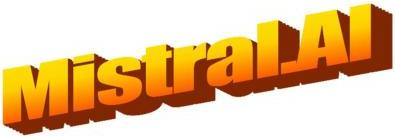
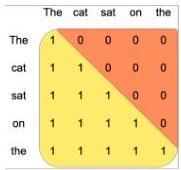
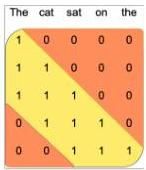
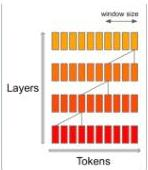
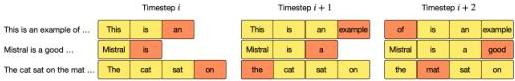
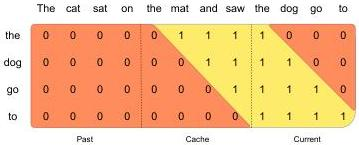
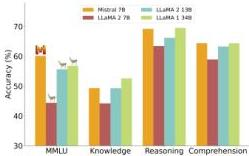
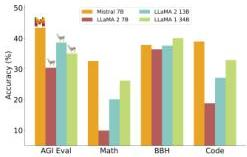
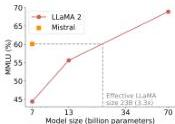
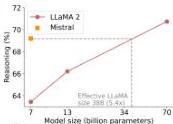
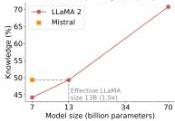
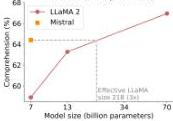
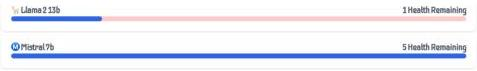
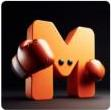

In [7]:
from mistralai.client.models import OCRResponse
from IPython.display import HTML, display
import markdown

def replace_images_in_markdown(markdown_str: str, images_dict: dict) -> str:
    """
    Replace image placeholders in markdown with base64-encoded images.

    Args:
        markdown_str: Markdown text containing image placeholders
        images_dict: Dictionary mapping image IDs to base64 strings

    Returns:
        Markdown text with images replaced by base64 data
    """
    for img_name, base64_str in images_dict.items():
        markdown_str = markdown_str.replace(
            f"![{img_name}]({img_name})", f"![{img_name}]({base64_str})"
        )
    return markdown_str

def confidence_color(score_pct: float) -> str | None:
    """Map a 0–100 confidence score to a display color."""
    if score_pct < 60:
        return "#d32f2f"  # red
    if score_pct < 80:
        return "#ef6c00"  # orange
    if score_pct < 95:
        return "#f9a825"  # yellow
    return "#ffffff" # White

def apply_confidence_colors(markdown_str: str, word_scores) -> str:
    """Wrap each OCR word in a colored span based on its confidence score."""
    if not word_scores:
        return markdown_str

    colored = markdown_str
    for word in sorted(word_scores, key=lambda w: w.start_index, reverse=True):
        start = word.start_index
        end = start + len(word.text)
        text = colored[start:end]
        if text != word.text:
            continue

        score_pct = word.confidence * 100
        color = confidence_color(score_pct)
        if color is None:
            continue
        colored = (
            colored[:start]
            + f'<span style="color: {color};" title="{score_pct:.1f}%">{text}</span>'
            + colored[end:]
        )
    return colored

def get_combined_markdown(ocr_response: OCRResponse) -> str:
    """
    Combine OCR text and images into a single markdown document.

    Words are color-coded by OCR confidence when word-level scores are available.

    Args:
        ocr_response: Response from OCR processing containing text and images

    Returns:
        Combined markdown string with embedded images and confidence coloring
    """
    markdowns: list[str] = []
    for page in ocr_response.pages:
        page_md = page.markdown
        if page.confidence_scores and page.confidence_scores.word_confidence_scores:
            page_md = apply_confidence_colors(
                page_md, page.confidence_scores.word_confidence_scores
            )

        image_data = {img.id: img.image_base64 for img in page.images}
        markdowns.append(replace_images_in_markdown(page_md, image_data))

    return "\n\n".join(markdowns)

# Keep all your existing functions, then:
html_output = markdown.markdown(get_combined_markdown(pdf_response))
display(HTML(html_output))

## Mistral OCR with Annotations
First, we need to create our Annotation Formats, for that we advise make use of `pydantic`.  
For this example, we will extract the image type and a description of each bbox; as well as the language, authors and a summary of the full document.

*For this section, we will not use confidence scores.*

In [8]:
from pydantic import BaseModel, Field
from enum import Enum

class ImageType(str, Enum):
    GRAPH = "graph"
    TEXT = "text"
    TABLE = "table"
    IMAGE = "image"

class Image(BaseModel):
    image_type: ImageType = Field(..., description="The type of the image. Must be one of 'graph', 'text', 'table' or 'image'.")
    description: str = Field(..., description="A description of the image.")

class Document(BaseModel):
    language: str = Field(..., description="The language of the document in ISO 639-1 code format (e.g., 'en', 'fr').")
    summary: str = Field(..., description="A summary of the document.")
    authors: list[str] = Field(..., description="A list of authors who contributed to the document.")


Now with our pydantic models created for our Annotations, we can call our OCR endpoint.  
The objective is to Annotate and Extract information from our document and the bbox/images detected.

In [9]:
from mistralai.extra import response_format_from_pydantic_model

# OCR Call with Annotations
annotations_response = client.ocr.process(
    model="mistral-ocr-latest",
    pages=list(range(8)), # Document Annotations has a limit of 8 pages, we recommend spliting your documents when using it; bbox annotations does not have the same limit
    document={
        "type": "document_url",
        "document_url": f"data:application/pdf;base64,{base64_pdf}"
    },
    bbox_annotation_format=response_format_from_pydantic_model(Image),
    document_annotation_format=response_format_from_pydantic_model(Document),
    include_image_base64=False # We are not interested on retrieving the bbox images in this example, only their annotations
  )

# Convert response to JSON format
response_dict = json.loads(annotations_response.model_dump_json())

print(json.dumps(response_dict, indent=4))

{
    "pages": [
        {
            "index": 0,
            "markdown": "arXiv:2310.06825v1 [cs.CL] 10 Oct 2023\n\n# Mistral 7B\n\nAlbert Q. Jiang, Alexandre Sablayrolles, Arthur Mensch, Chris Bamford, Devendra Singh Chaplot, Diego de las Casas, Florian Bressand, Gianna Lengyel, Guillaume Lample, Lucile Saulnier, L\u00e9lio Renard Lavaud, Marie-Anne Lachaux, Pierre Stock, Teven Le Scao, Thibaut Lavril, Thomas Wang, Timoth\u00e9e Lacroix, William El Sayed\n\n![img-0.jpeg](img-0.jpeg)\n\n## Abstract\n\nWe introduce Mistral 7B, a 7-billion-parameter language model engineered for superior performance and efficiency. Mistral 7B outperforms the best open 13B model (Llama 2) across all evaluated benchmarks, and the best released 34B model (Llama 1) in reasoning, mathematics, and code generation. Our model leverages grouped-query attention (GQA) for faster inference, coupled with sliding window attention (SWA) to effectively handle sequences of arbitrary length with a reduced inference cost

Let's print the Annotations only!

In [10]:
print("Document Annotation:\n", annotations_response.document_annotation)
print("\nBBox/Images:")
for page in annotations_response.pages:
    for image in page.images:
        print("\nImage", image.id)
        print("Location:")
        print(" - top_left_x:", image.top_left_x)
        print(" - top_left_y:", image.top_left_y)
        print(" - bottom_right_x:", image.bottom_right_x)
        print(" - bottom_right_y:", image.bottom_right_y)
        print("BBox/Image Annotation:\n", image.image_annotation)

Document Annotation:
 {"language": "en", "summary": "The document introduces Mistral 7B, a 7-billion-parameter language model designed for high performance and efficiency. Key features include grouped-query attention (GQA) for faster inference and sliding window attention (SWA) to handle long sequences with reduced computational cost. Mistral 7B outperforms the best open 13B model (Llama 2) across all benchmarks and surpasses the best released 34B model (Llama 1) in reasoning, mathematics, and code generation. The model also includes a fine-tuned version, Mistral 7B – Instruct, which excels in instruction-following tasks. Mistral 7B leverages architectural innovations like rolling buffer cache and pre-fill/chunking for efficient inference. It is released under the Apache 2.0 license, with code and resources available on GitHub and Hugging Face. The document also discusses the model's efficiency, guardrails for safe deployment, and its ability to perform content moderation via self-refl

## Full Document with Annotation
For reference, let's do the same but including the bbox images.

In [11]:
# OCR Call with Annotations
annotations_response = client.ocr.process(
    model="mistral-ocr-latest",
    pages=list(range(8)), # Document Annotations has a limit of 8 pages, we recommend spliting your documents when using it; bbox annotations does not have the same limit
    document={
        "type": "document_url",
        "document_url": f"data:application/pdf;base64,{base64_pdf}"
    },
    bbox_annotation_format=response_format_from_pydantic_model(Image),
    document_annotation_format=response_format_from_pydantic_model(Document),
    include_image_base64=True
  )

Now, we will display the full document with the OCR content and the annotation in bold:
- Document Annotation at the start of the document.
- BBox Annotation at below each bbox/image extracted.


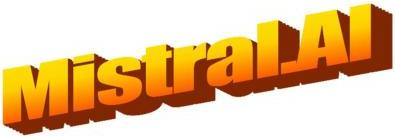
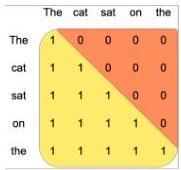
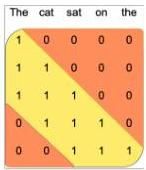
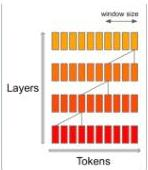
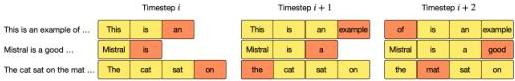
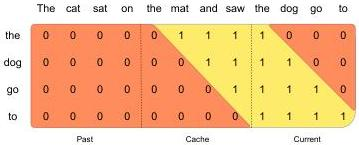
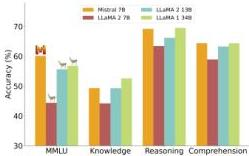
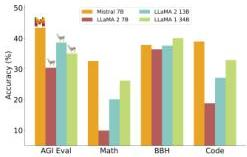
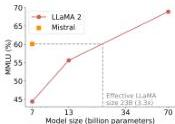
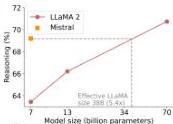
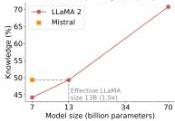
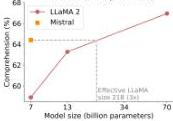
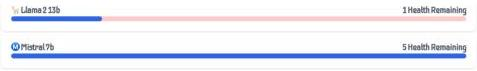
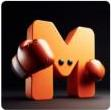

In [12]:
def replace_images_in_markdown_annotated(markdown_str: str, images_dict: dict) -> str:
    """
    Replace image placeholders in markdown with base64-encoded images and their annotation.

    Args:
        markdown_str: Markdown text containing image placeholders
        images_dict: Dictionary mapping image IDs to base64 strings

    Returns:
        Markdown text with images replaced by base64 data and their annotation
    """
    for img_name, data in images_dict.items():
        markdown_str = markdown_str.replace(
            f"![{img_name}]({img_name})", f"![{img_name}]({data['image']})\n\n**{data['annotation']}**"
        )
    return markdown_str

def get_combined_markdown_annotated(ocr_response: OCRResponse) -> str:
    """
    Combine OCR text, annotation and images into a single markdown document.

    Args:
        ocr_response: Response from OCR processing containing text and images

    Returns:
        Combined markdown string with embedded images and their annotation
    """
    markdowns: list[str] = ["**" + ocr_response.document_annotation + "**"]
    # Extract images from page
    for page in ocr_response.pages:
        image_data = {}
        for img in page.images:
            image_data[img.id] = {"image":img.image_base64, "annotation": img.image_annotation}
        # Replace image placeholders with actual images
        markdowns.append(replace_images_in_markdown_annotated(page.markdown, image_data))

    return "\n\n".join(markdowns)

# Display combined markdowns and images
html_output = markdown.markdown(get_combined_markdown_annotated(annotations_response))
display(HTML(html_output))

## Other Examples


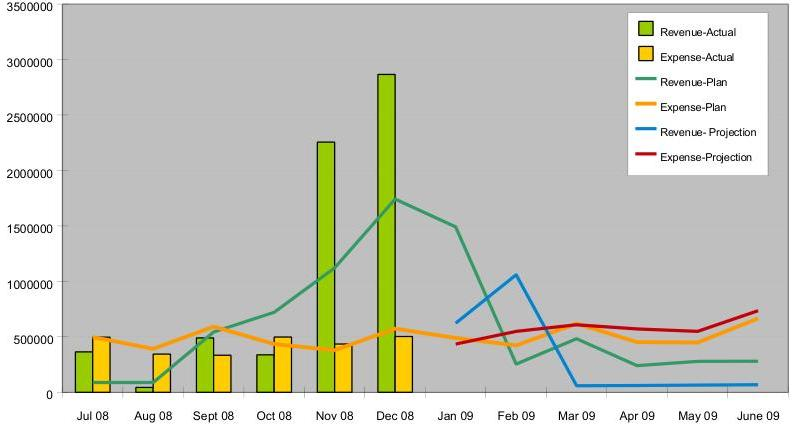

In [13]:
#@title PDF Financial Document

# Create the annotations formats
class ImageType(str, Enum):
    GRAPH = "graph"
    TEXT = "text"
    TABLE = "table"
    IMAGE = "image"

class Image(BaseModel):
    image_type: ImageType = Field(..., description="The type of the image. Must be one of 'graph', 'text', 'table' or 'image'.")
    description: str = Field(..., description="A description of the image.")

class Document(BaseModel):
    languages: list[str] = Field(..., description="The list of languages present in the document in ISO 639-1 code format (e.g., 'en', 'fr').")
    summary: str = Field(..., description="A summary of the document.")

# OCR Call with Annotations
annotations_response = client.ocr.process(
    model="mistral-ocr-latest",
    pages=list(range(8)), # Document Annotations has a limit of 8 pages, we recommend spliting your documents when using it; bbox annotations does not have the same limit
    document={
        "type": "document_url",
        "document_url": "https://upload.wikimedia.org/wikipedia/foundation/f/f6/WMF_Mid-Year-Financials_08-09-FINAL.pdf"
    },
    bbox_annotation_format=response_format_from_pydantic_model(Image),
    document_annotation_format=response_format_from_pydantic_model(Document),
    include_image_base64=True
  )

# Display combined markdowns and images
html_output = markdown.markdown(get_combined_markdown_annotated(annotations_response))
display(HTML(html_output))